The problem we are attempting to continue the development of our app in assignment 5. Now we are 
now clustering our data to assess how well a clustering system will work on our dataset. This allows us to assess how well defined each letter is within it's class and find out if there are any issues within the dataset. 

## Step 1, Data Review

In [1]:
import pandas as pd

In [2]:
data = pd.read_csv('csvImages 10k x 784.csv')

### Converting our Data into a more readable format
We need to do this as these are all images as pixel valeus, and are coloured pixel value

In [3]:
# This function simply gathers the values and returns an array of values without column 
# seperation
data_array = data.values

In [4]:
# Checking what shape our array is
print(data_array.shape)
# should be 10000 images that are 28x28 or 784 pixels

(9999, 784)


In [5]:
# We are simply normalizing pixel values, essentially removing some colour depth
# for efficiency
normalized = data_array/255

In [6]:
import numpy as np
import matplotlib.pyplot as plt

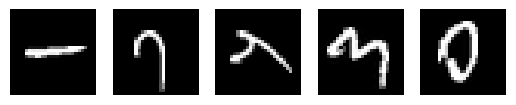

In [7]:
# Plotting the first 5 images
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(normalized[i].reshape(28, 28), cmap='gray')  # Reshape and use gray colormap
    plt.axis('off')   
plt.show()

In [8]:
normalized[1].shape

(784,)

## Step 2.1, Using PCA to reduce our dimensionality

In [9]:
from sklearn.decomposition import PCA

In [10]:
# initializing PCA as requested in Assignment
pca_model = PCA(n_components=40)

Why use Principle component analysis?<br>
It makes sense to use PCA for this as there is a lot of noise in our data due to the "blank" spaces in the data that do not represent the patterns we are looking for and without these patterns we cannot properly use clustering to classify our images correctly.<br>
As an added bonus, we can reduce the dimensionality of our data which will reduce the computational power required to cluster our data. A win win. 

In [11]:
minimized = pca_model.fit_transform(normalized)

## Step 2.2, Clustering using tried and true methods
### K-means

In [12]:
from sklearn.cluster import KMeans

In [13]:
# importing scoring metrics, this is sort of important for all clustering
from sklearn.metrics import silhouette_score as sscor
from sklearn.metrics import davies_bouldin_score as dbs

In [14]:
# lets try a few different models for Kmeans to see some results

# first lets establish some variables to store our results
klist = [] # to store our models
resultskm = []

In [15]:
# reusing an old cell from another assignment as this is very well done
for i in [6,8,10,12,14,16]:
    temp = KMeans(n_clusters=i)
    preds = temp.fit_predict(minimized)
    
    # Calculating scores and storing them in metrics
    try:# this section tests how well our models preform
        ss = sscor(minimized, preds)
    except Exception as e: # if there is a problem we do not stop but catch the error and return a 'Bad' value
        print('Silhouette', e) # for my knowledge of what errors occur
        ss = -1
    try:
        david = dbs(minimized, preds)
    except Exception as e:
        print('David: ', e)
        david = 2
        
    # combining everything and storing it
    resultskm.append({'Clusters': i, 'Silhouette Score': ss, 'Davies Bouldin Score': david})
    klist.append(temp)

In [16]:
resultskm = pd.DataFrame.from_dict(resultskm)

In [17]:
resultskm

,Clusters,Davies Bouldin Score,Silhouette Score
0,6,2.153043,0.121331
1,8,2.177903,0.115942
2,10,2.175990,0.121656
3,12,2.090655,0.132457
4,14,2.145772,0.131978
5,16,2.094353,0.134651


Whew, that was more intensive than I thought. Comes out much prettier than my original usage. 
Looking at our Kmeans scores, I can assume that our data does not have very clear circular clusters. Though KMeans does not seem to preform well initially, this does tell us our patterns do not result in cleanly shaped clusters tgus requiring more advanced data clsutering methods. 

### Heirarchical Clustering
We are sticking to Agglomerative clustering as I do not overly feel like implamenting divisive clustering at this time.

In [18]:
from sklearn.cluster import AgglomerativeClustering

In [19]:
# Lets define some parameters for our clustering models
paramsAgg = [
    {'n_clusters': 7, 'metric': 'euclidean', 'linkage': 'ward', 'distance_threshold':None},
    {'n_clusters': 9, 'metric': 'euclidean', 'linkage': 'ward', 'distance_threshold':None},
    {'n_clusters': 6, 'metric': 'euclidean', 'linkage': 'complete', 'distance_threshold':None},
    {'n_clusters': 6, 'metric': 'manhattan', 'linkage': 'average', 'distance_threshold':None},
    {'n_clusters': None, 'metric': 'euclidean', 'linkage': 'ward', 'distance_threshold': 1},
    {'n_clusters': None, 'metric': 'euclidean', 'linkage': 'ward', 'distance_threshold': 2.0},
    {'n_clusters': None, 'metric': 'euclidean', 'linkage': 'complete', 'distance_threshold': 0.75},
    {'n_clusters': None, 'metric': 'cosine', 'linkage': 'average', 'distance_threshold': 0.5},
    {'n_clusters': 10, 'metric': 'manhattan', 'linkage': 'single', 'distance_threshold':None},
    {'n_clusters': 10, 'metric': 'cosine', 'linkage': 'complete', 'distance_threshold':None},
]

# now lets make us two lists to store our models and results
resultsagg = []
agglist = []

In [20]:
for i in paramsAgg:
    temp = AgglomerativeClustering(n_clusters=i['n_clusters'],
                                   affinity=i['metric'],
                                   linkage=i['linkage'],
                                   distance_threshold=i['distance_threshold'])
    preds = temp.fit_predict(minimized)
    
    # Calculating scores and storing them in metrics
    # Calculating scores and storing them in metrics
    try:# this section tests how well our models preform
        ss = sscor(minimized, preds)
    except Exception as e: # if there is a problem we do not stop but catch the error and return a 'Bad' value
        print('Silhouette', e) # for my knowledge of what errors occur
        ss = -1
    try:
        david = dbs(minimized, preds)
    except Exception as e:
        print('David: ', e)
        david = 2
        
    # combining everything and storing it
    resultsagg.append({ 'n_clusters': i['n_clusters'],
                        'metric': i['metric'],
                        'linkage': i['linkage'],
                        'distance threshold': i['distance_threshold'],
                        'Silhouette Score': ss,
                        'Davies Bouldin Score': david})
    agglist.append(temp)
resultsagg = pd.DataFrame(resultsagg)

In [21]:
resultsagg[['Davies Bouldin Score','Silhouette Score']]

,Davies Bouldin Score,Silhouette Score
0,2.329080,0.107673
1,2.231689,0.114460
2,2.300050,0.093022
3,1.595591,0.150843
4,0.127780,0.015202
5,0.403752,0.072250
6,0.087972,0.008306
7,1.617035,0.059095
8,0.688374,0.039472
9,2.849955,0.060958


Well well, We still aren't getting great scores sadly. Seems that our data is quite odd, or perhaps 
I need to expand my clusters in some way. If I understand our data correctly we need around 10 clusters so our models not preforming well is concerning. Well, onto my favourite clustering system!!

### DBSCAN

In [22]:
# first lets import our model
from sklearn.cluster import DBSCAN

In [23]:
# lets set up some parameters
DBparms = [{'EPS': 0.5,'Min_Samples': 5,'Metric': 'euclidean','Algorithm': 'auto','Leaf_size': 30},
           {'EPS': 0.3,'Min_Samples': 7,'Metric': 'euclidean','Algorithm': 'auto','Leaf_size': 30},
           {'EPS': 0.5,'Min_Samples': 3,'Metric': 'euclidean','Algorithm': 'auto','Leaf_size': 30},
           {'EPS': 0.55,'Min_Samples': 4,'Metric': 'euclidean','Algorithm': 'auto','Leaf_size': 30},
           # Lets use some different distance metrics to test which may fit out data better
           {'EPS': 0.5,'Min_Samples': 5,'Metric': 'cityblock','Algorithm': 'auto','Leaf_size': 30},
           {'EPS': 0.5,'Min_Samples': 5,'Metric': 'cosine','Algorithm': 'auto','Leaf_size': 30},
           {'EPS': 0.5,'Min_Samples': 5,'Metric': 'manhattan','Algorithm': 'auto','Leaf_size': 30},
           # Lets try some combinations to see what may fit well in our first round of testing
           {'EPS': 0.6,'Min_Samples': 7,'Metric': 'cosine','Algorithm': 'auto','Leaf_size': 30},
           {'EPS': 0.6,'Min_Samples': 7,'Metric': 'cityblock','Algorithm': 'brute','Leaf_size': 40},
           {'EPS': 0.8,'Min_Samples': 5,'Metric': 'euclidean','Algorithm': 'brute','Leaf_size': 100}]

# now lets set up some results variables
resultsdb = []
DBlist = []

In [24]:
for hyp in DBparms:
    # setting up our model and it's parameteres
    temp = DBSCAN(eps=hyp['EPS'], 
                  min_samples=hyp['Min_Samples'], 
                  metric=hyp['Metric'], 
                  algorithm=hyp['Algorithm'], 
                  leaf_size=hyp['Leaf_size']
                 )
    
    # clustering the data and predicting labels of scaled data
    preds = temp.fit_predict(minimized)
    
    # Calculating scores and storing them in metrics
    # Calculating scores and storing them in metrics
    try:# this section tests how well our models preform
        ss = sscor(minimized, preds)
    except Exception as e: # if there is a problem we do not stop but catch the error and return a 'Bad' value
        print('Silhouette', e) # for my knowledge of what errors occur
        ss = -1
    try:
        david = dbs(minimized, preds)
    except Exception as e:
        print('David: ', e)
        david = 2
        
    # Combining all results, storing model, and finishing iteration
    resultsdb.append({'EPS': hyp['EPS'],
                      'Min Samples': hyp['Min_Samples'],
                      'Metric': hyp['Metric'],
                      'Algorithm': hyp['Algorithm'],
                      'Leaf size': hyp['Leaf_size'],
                      'Silhouette Score': ss,
                      'Davies Bouldin Score': david
                      })
    DBlist.append(temp)
resultsdb = pd.DataFrame(resultsdb)

Silhouette Number of labels is 1. Valid values are 2 to n_samples - 1 (inclusive)
David:  Number of labels is 1. Valid values are 2 to n_samples - 1 (inclusive)
Silhouette Number of labels is 1. Valid values are 2 to n_samples - 1 (inclusive)
David:  Number of labels is 1. Valid values are 2 to n_samples - 1 (inclusive)
Silhouette Number of labels is 1. Valid values are 2 to n_samples - 1 (inclusive)
David:  Number of labels is 1. Valid values are 2 to n_samples - 1 (inclusive)
Silhouette Number of labels is 1. Valid values are 2 to n_samples - 1 (inclusive)
David:  Number of labels is 1. Valid values are 2 to n_samples - 1 (inclusive)
Silhouette Number of labels is 1. Valid values are 2 to n_samples - 1 (inclusive)
David:  Number of labels is 1. Valid values are 2 to n_samples - 1 (inclusive)
Silhouette Number of labels is 1. Valid values are 2 to n_samples - 1 (inclusive)
David:  Number of labels is 1. Valid values are 2 to n_samples - 1 (inclusive)


In [25]:
resultsdb[['Davies Bouldin Score','Silhouette Score']]

,Davies Bouldin Score,Silhouette Score
0,1.299384,-0.163686
1,2.000000,-1.000000
2,1.278654,-0.192125
3,1.311762,-0.191138
4,2.000000,-1.000000
5,2.000000,-1.000000
6,2.000000,-1.000000
7,2.000000,-1.000000
8,2.000000,-1.000000
9,1.326291,-0.179297


Uh oh. Even the big guns cannot handle this dataset. This is concerning. <br><br>Our best Model comes from 
Agglomerative clustering with a silhouette score of 0.16., we can likely see better with more clusters but even then our scores suggest that our data is not well suited to clustering with more traditional techniques. <br><br>We are looking at images and not numerical relations. PCA isn't meant to look at this kind of high dimensional data. We need a more specialized method that can look at high dimensional data without losing our more localized relations in our data!

In [26]:
resultsagg.loc[4]

Davies Bouldin Score      0.12778
Silhouette Score        0.0152025
distance threshold              1
linkage                      ward
metric                  euclidean
n_clusters                    NaN
Name: 4, dtype: object

In [27]:
# generating our best model from KMeans for labelling purposes
best_model = AgglomerativeClustering(linkage='average', affinity='manhattan', n_clusters=6)
labels = best_model.fit_predict(minimized)

## Step 3, t-SNE Clustering
What is t-Distributed Stochastic Neighbor Embedding Clustering? <br>
t-SNE is a powerful method for visualizing high-dimensional data in a lower-dimensional space (usually 2D or 3D) by preserving local data relationships. It calculates a probabilistic similarity matrix based on distances between points in the high-dimensional space and then arranges points in the lower-dimensional space to reflect these similarities. Through this process, t-SNE focuses on capturing local patterns and clusters, allowing for a meaningful representation of the data's structure in reduced dimensions.

In [28]:
# lets begin playing with the t-SNE method
from sklearn.manifold import TSNE

In [29]:
# setting up marker list for our model, we want to see the representations of the roman numerals
MARKER = ['o', 'v', '1', 'p' ,'*', '+', 'x', 'd', '4', '.']

C:\Users\Danton\anaconda3\envs\UnsupervisedML\lib\site-packages\ipykernel_launcher.py:11: RuntimeWarning: Mean of empty slice.
  # This is added back by InteractiveShellApp.init_path()
C:\Users\Danton\anaconda3\envs\UnsupervisedML\lib\site-packages\numpy\core\_methods.py:78: RuntimeWarning: invalid value encountered in true_divide
  ret, rcount, out=ret, casting='unsafe', subok=False)
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


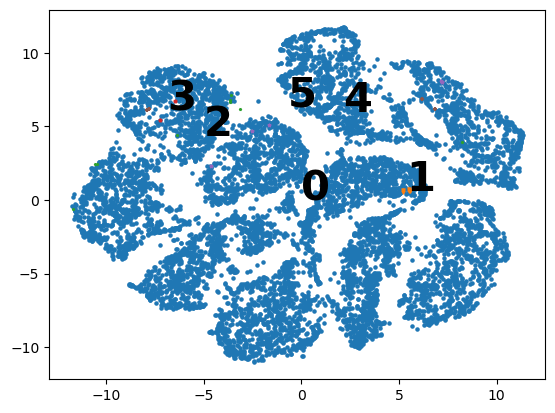

In [30]:
n, m, p = 300, 'euclidean', 30
temp = TSNE(n_iter=n,
            metric=m,
            perplexity=p,
            random_state=0
            )
temp_data = temp.fit_transform(minimized)
for i in range(10):
    selections = temp_data[labels == i]
    plt.scatter(selections[:,0], selections[:,1], marker=MARKER[i], s=5)
    x, y = selections.mean(axis=0)
    plt.text(x, y, str(i), fontdict={'weight': 'bold', 'size': 30})    
plt.show()

Our model isn't capturing the whole picture here. We see very good patterns here and how well our 
potential clusters look with this fairly basic model now. It is promising that we could potentially gather some very good clustering data for our algorithms later. Now we need to ensure that our clusters are indeed worthwhile. 

### Testing t-SNE Hyperparameters
Here we are going through a list of hyperparameters in a search to assess how effect t-SNe is going to be! We should get 27 unique charts to show us a 2D representation of the system!

In [31]:
# Since we want to create multiple iterations of t-SNE we will make a few lists of parameters
perplex = [10,30,50] # related to the number of nearest neighbours in other methods
n_it = [300, 375, 450] # number of max iterations for optimization
met = ['euclidean','cityblock','cosine'] # the metric used in the distance calculation

# setting some storage variables to ensure our data 
resultstsne = []

### Euclidean Distance

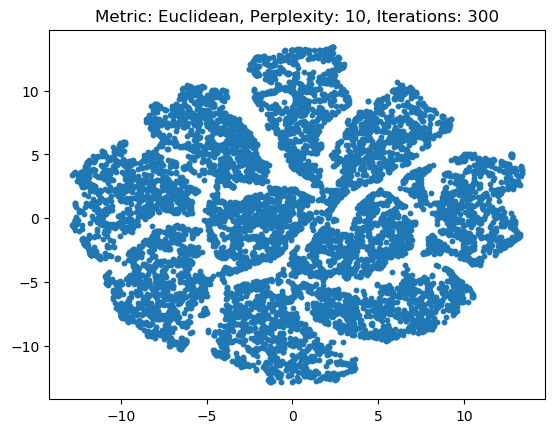

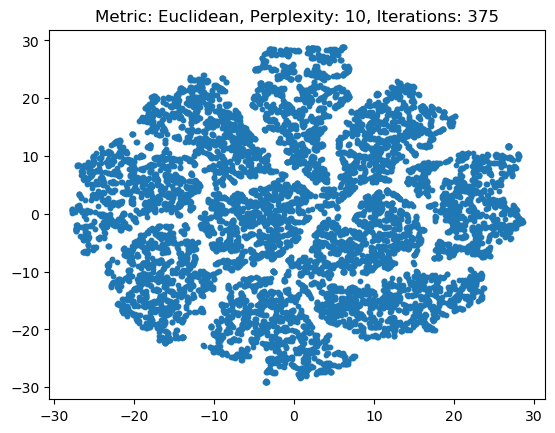

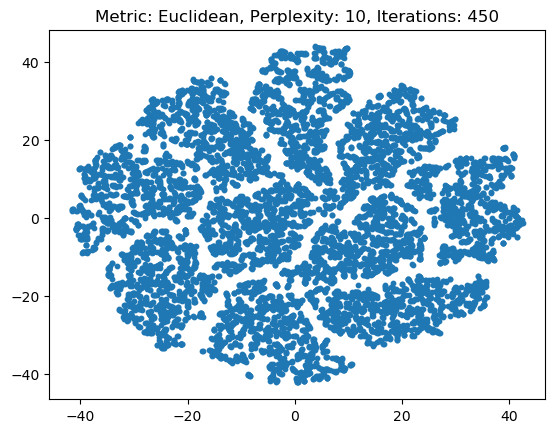

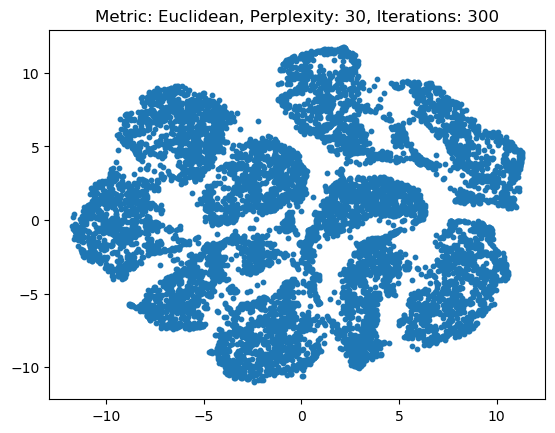

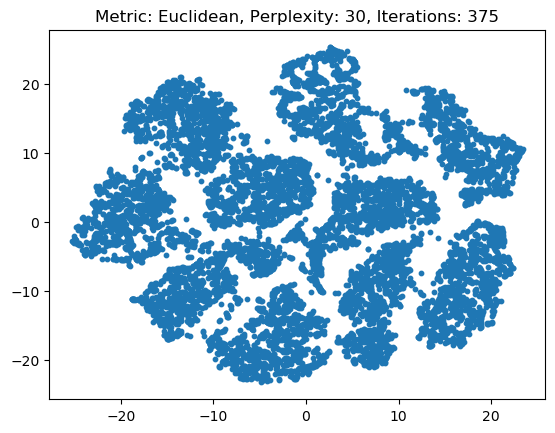

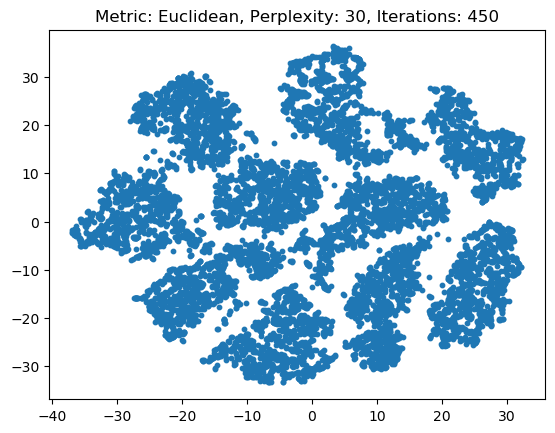

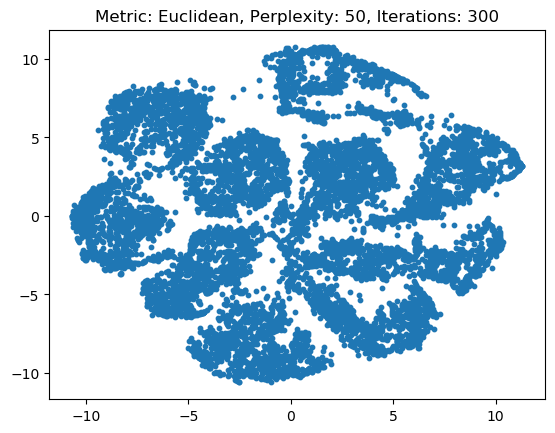

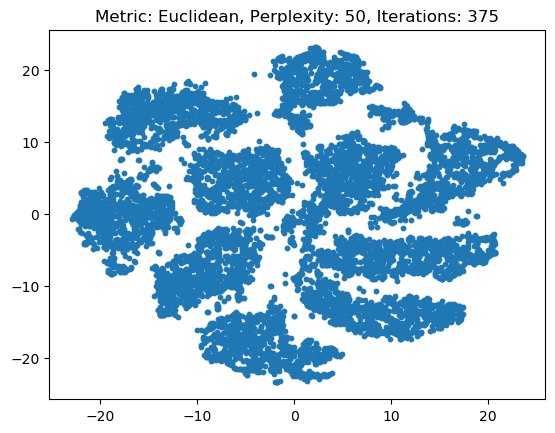

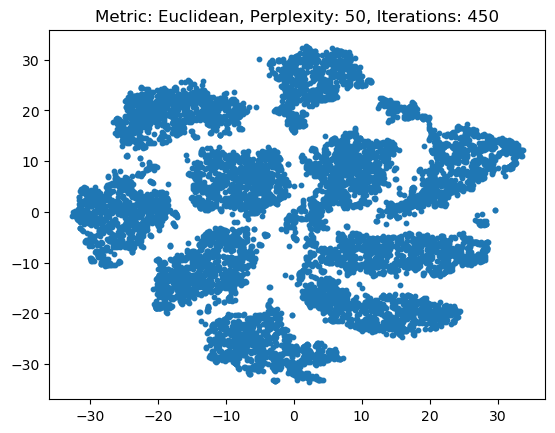

In [32]:
for p in perplex: # we have 3 perplexity values
    for n in n_it:# we have 3 iteration values, this should print 9 charts, total 27 for entire search 
        temp = TSNE(n_iter=n,
                    metric='euclidean',
                    perplexity=p,
                    random_state=0# ensuring repeatability
                    )
        temp_data = temp.fit_transform(minimized)
        plt.scatter(temp_data[:,0], temp_data[:,1], cmap='tab10', s=10)
        plt.title(f"Metric: Euclidean, Perplexity: {p}, Iterations: {n}")
        plt.show()
        # Storing results incase needed again
        resultstsne.append({'Metric': 'euclidean',
                            'N_Iter': n,
                            'Perplexity': p,
                            })

### Manhattan Distance Metric

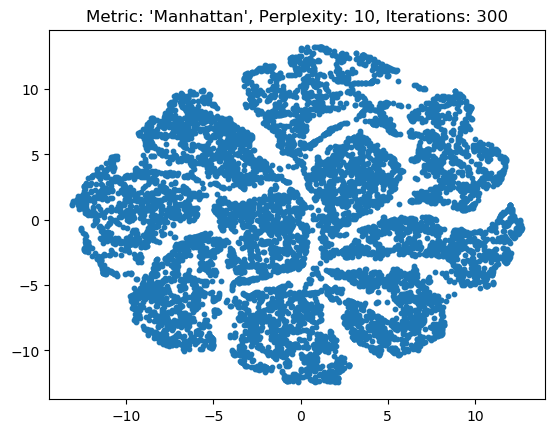

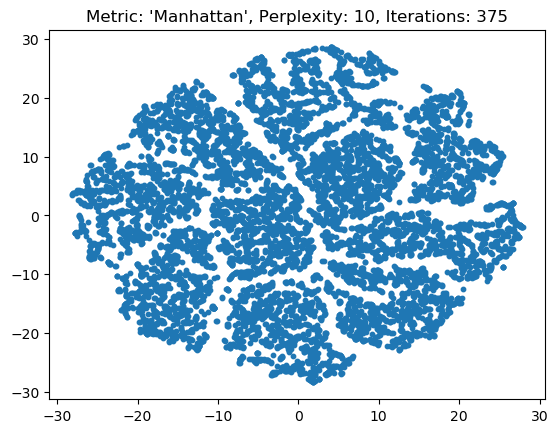

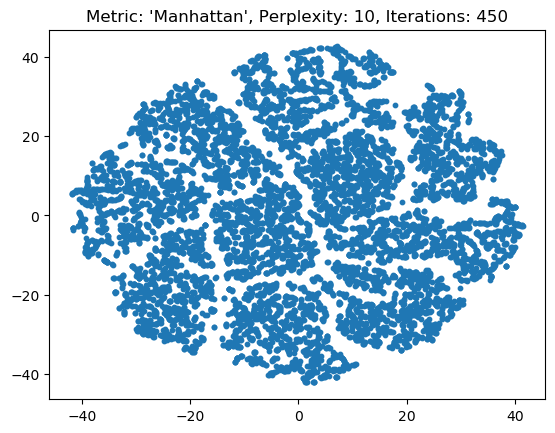

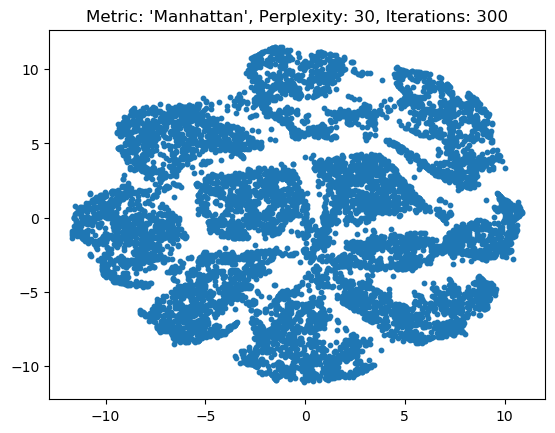

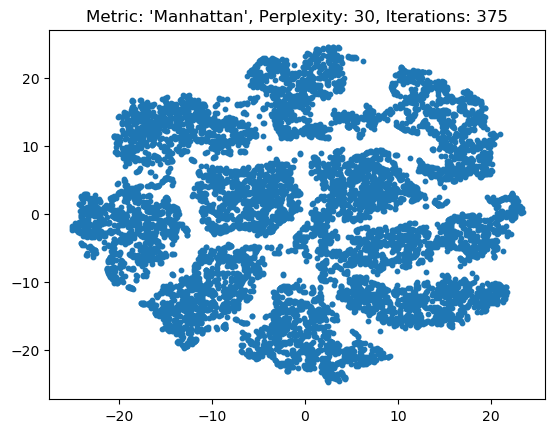

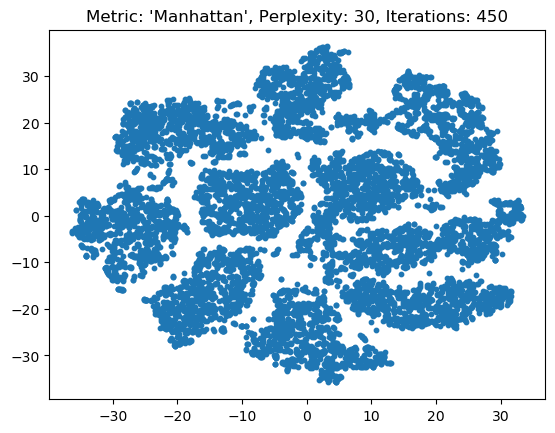

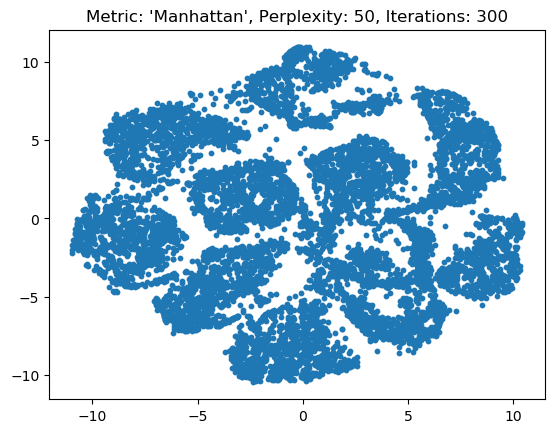

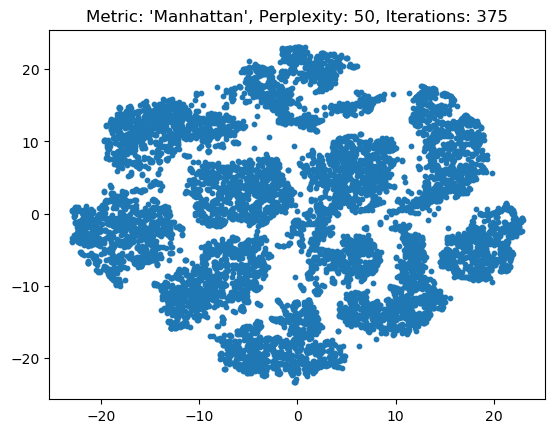

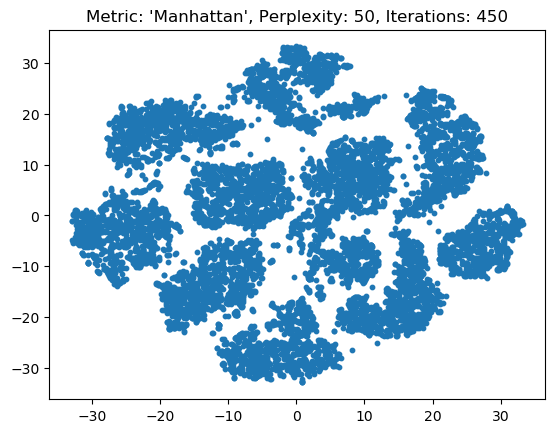

In [33]:
for p in perplex: # we have 3 perplexity values
    for n in n_it:# we have 3 iteration values, this should print 9 charts
        temp = TSNE(n_iter=n,
                    metric='manhattan',
                    perplexity=p,
                    random_state=0# ensuring repeatability
                    )
        temp_data = temp.fit_transform(minimized)
        plt.scatter(temp_data[:,0], temp_data[:,1], cmap='tab10', s=10)
        plt.title(f"Metric: 'Manhattan', Perplexity: {p}, Iterations: {n}")
        plt.show()
        # Storing results incase needed again
        resultstsne.append({'Metric': 'manhattan',
                            'N_Iter': n,
                            'Perplexity': p,
                            })

### Cosine Distance Metric

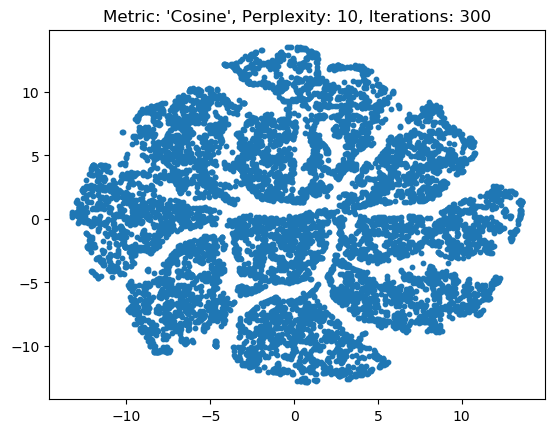

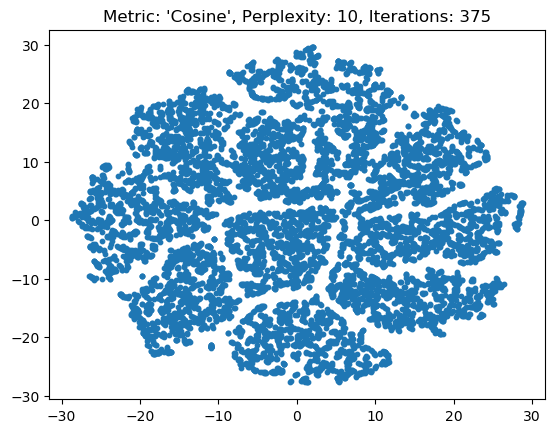

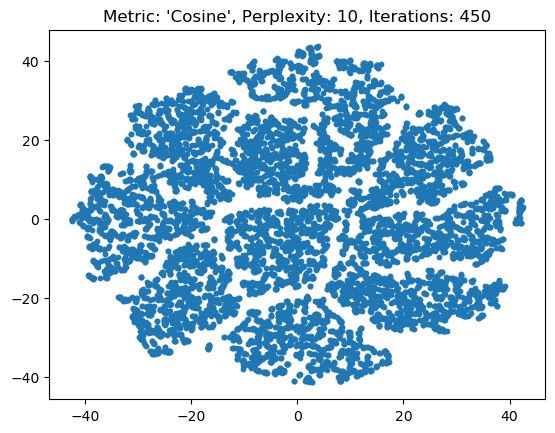

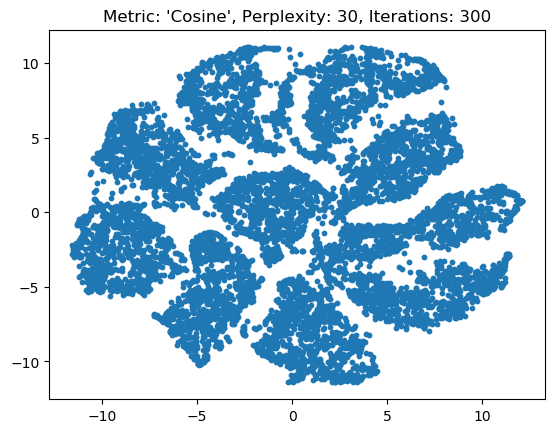

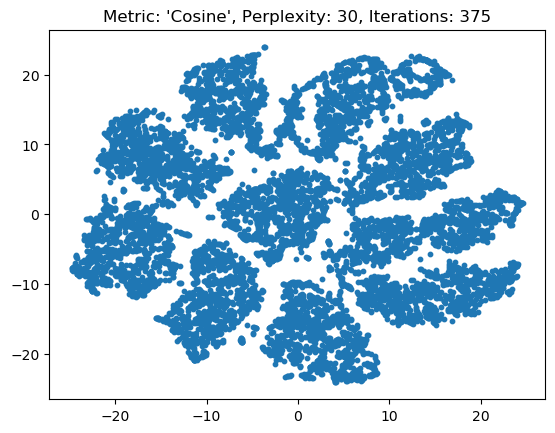

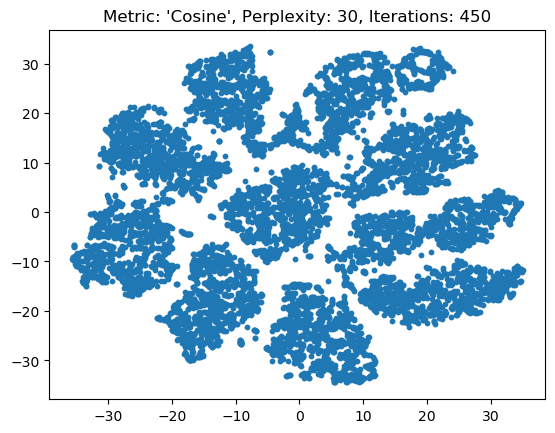

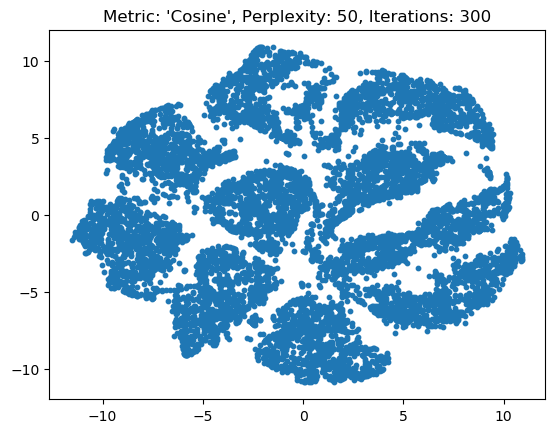

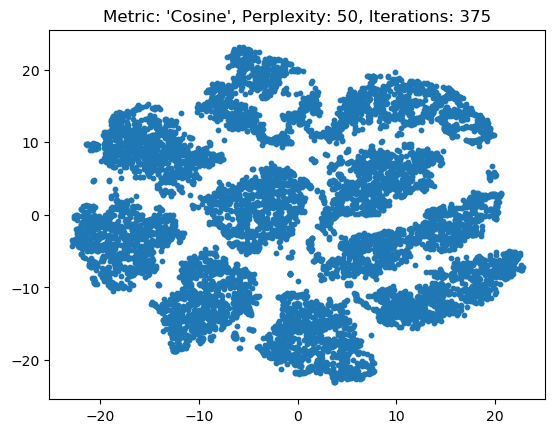

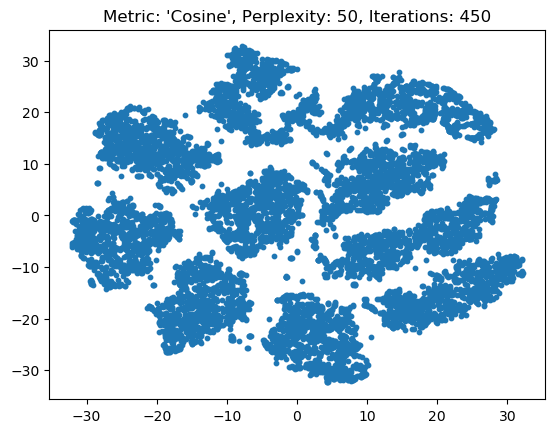

In [34]:
for p in perplex: # we have 3 perplexity values
    for n in n_it:# we have 3 iteration values, this should print 9 charts 
        temp = TSNE(n_iter=n,
                    metric='cosine',
                    perplexity=p,
                    random_state=0# ensuring repeatability
                    )
        temp_data = temp.fit_transform(minimized)
        plt.scatter(temp_data[:,0], temp_data[:,1], cmap='tab10', s=10)
        plt.title(f"Metric: 'Cosine', Perplexity: {p}, Iterations: {n}")
        plt.show()
        # Storing results incase needed again
        resultstsne.append({'Metric': 'cosine',
                            'N_Iter': n,
                            'Perplexity': p,
                            })

### Examining our results
We want a t-sne representation that shows us a very clear and defined pattern of around 10 clusters. So far the best representations are from models with high perplexity and iterations. So it suggests we want our models to have higher iteration values to ensure better. Initial tests showed this trend, and also quite a bit of mutability within our dataset due to having no random state set. Something that will have to be fixed in a later entry.
<br><br>
**Update from the Future!**<br>
After running an initial test we could see some really good results with what looked like a cosine distance metric. Perplexity had a lesser affect when compared to iteration values so the n_iteration values were upped to compensate for this. 
<br><br>
**Update 2, the final one!**<br>
Well we see that a larger number of iterations does in fact make my computer less happy but helps us look at some much more interesting results, we see a few very good models that will help us label our clusters. Here are our top choices:

    1. Euclidean Metric with Perplexity 30 and Iteration count of 450
    2. Euclidean Metric with Perplexity 50 and Iteration count of 450
    3. Cosine Metric with Perplexity 50 and Iteration count of 450
As this shows euclidean preformed much better in this round of testing as a result of upping our iteration counts. Cool!

### Judging our best and brightest!

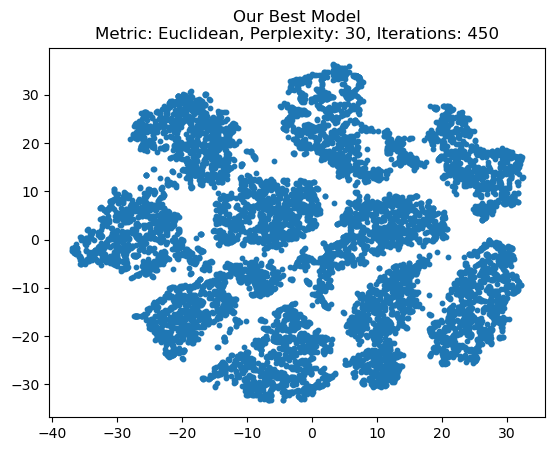

In [35]:
# I feel that our first choice is likely the best moving forward. Let's continue on
tsne_model = TSNE(n_iter=450,
                 metric='euclidean',
                 perplexity=30,
                 random_state=0# ensuring repeatability
                )
# now we fit the model to our data and continue labelling our data
tsne_data = tsne_model.fit_transform(minimized)

plt.scatter(tsne_data[:,0], tsne_data[:,1], cmap='tab10', s=10)
plt.title("Our Best Model\nMetric: Euclidean, Perplexity: 30, Iterations: 450")
plt.show()

### Running a quick battery of model clustering models

#### KMeans

In [36]:
kmean_model = KMeans(n_clusters=10)# why 10? we know that there are 10 classes in our data
k_labels = kmean_model.fit_predict(tsne_data)

# Calculating scores and storing them in metrics
try:# this section tests how well our models preform
    ss = sscor(tsne_data, k_labels)
except Exception as e: # if there is a problem we do not stop but catch the error and return a 'Bad' value
    print('Silhouette', e) # for my knowledge of what errors occur
    ss = -1
try:
    david = dbs(tsne_data, k_labels)
except Exception as e:
    print('David: ', e)
    david = 2
    
print(f"Silhouette Score: {ss} and Davies Bouldin Score: {david}")

Silhouette Score: 0.45195314288139343 and Davies Bouldin Score: 0.7269077320807985


A dramatic improvement but we know KMeans can't classify our data too well due to the shape of our 
clusters!

#### Agglomerative Clustering

In [37]:
aggparams=[{'n_clusters': 10, 'metric': 'euclidean', 'linkage': 'ward', 'distance_threshold':None},
           {'n_clusters': None, 'metric': 'euclidean', 'linkage': 'ward', 'distance_threshold': 0.5}]

for i in aggparams:
    temp = AgglomerativeClustering(n_clusters=i['n_clusters'],
                                   affinity=i['metric'],
                                   linkage=i['linkage'],
                                   distance_threshold=i['distance_threshold'])
    preds = temp.fit_predict(tsne_data)
    
    # Calculating scores and storing them in metrics
    try:# this section tests how well our models preform
        ss = sscor(tsne_data, preds)
    except Exception as e: # if there is a problem we do not stop but catch the error and return a 'Bad' value
        print('Silhouette', e) # for my knowledge of what errors occur
        ss = -1
    try:
        david = dbs(tsne_data, preds)
    except Exception as e:
        print('David: ', e)
        david = 2

    print(f"Silhouette Score: {ss} and Davies Bouldin Score: {david}")

Silhouette Score: 0.42994630336761475 and Davies Bouldin Score: 0.8005213094249448
Silhouette Score: 0.4589214324951172 and Davies Bouldin Score: 0.46911566263475435


We are seeing some very good results in this round of quick modelling. I am 
going to keep things limited in our modelling as we know what we want to see in the end. Now onto DBSCAN!

#### DBSCAN

In [38]:
DBparms = [{'EPS': 0.5,'Min_Samples': 5,'Metric': 'euclidean','Algorithm': 'auto','Leaf_size': 30},
           {'EPS': 0.4,'Min_Samples': 3,'Metric': 'euclidean','Algorithm': 'auto','Leaf_size': 30},
           {'EPS': 0.45,'Min_Samples': 2,'Metric': 'euclidean','Algorithm': 'auto','Leaf_size': 50},
           {'EPS': 0.7,'Min_Samples': 8,'Metric': 'euclidean','Algorithm': 'auto','Leaf_size': 50}]

for hyp in DBparms:
    temp = DBSCAN(eps=hyp['EPS'], 
                  min_samples=hyp['Min_Samples'], 
                  metric=hyp['Metric'], 
                  algorithm=hyp['Algorithm'], 
                  leaf_size=hyp['Leaf_size']
                 )
    preds = temp.fit_predict(tsne_data)
    
    # Calculating scores and storing them in metrics
    try:# this section tests how well our models preform
        ss = sscor(tsne_data, preds)
    except Exception as e: # if there is a problem we do not stop but catch the error and return a 'Bad' value
        print('Silhouette', e) # for my knowledge of what errors occur
        ss = -1
    try:
        david = dbs(tsne_data, preds)
    except Exception as e:
        print('David: ', e)
        david = 2

    print(f"Silhouette Score: {ss} and Davies Bouldin Score: {david}")

Silhouette Score: 0.18201442062854767 and Davies Bouldin Score: 1.379319668299119
Silhouette Score: 0.23792575299739838 and Davies Bouldin Score: 1.3054973090990825
Silhouette Score: 0.21174734830856323 and Davies Bouldin Score: 1.4281636283018098
Silhouette Score: 0.12335691601037979 and Davies Bouldin Score: 1.320354285508015


## Step 4, Conclusions

### Who was best?
Agglomerative Clustering took the victory this time! Why? Agglomerative clustering doesn't require nicely shaped clusters like KMeans and is likely to give us the best representation of our data!

In [39]:
#Generating our model in the best_model variable
best_model = AgglomerativeClustering(n_clusters=10)# rest are default
# had to go with ten clusters as the other did not make ten clusters. Not even close. 
best_labels = best_model.fit_predict(tsne_data)

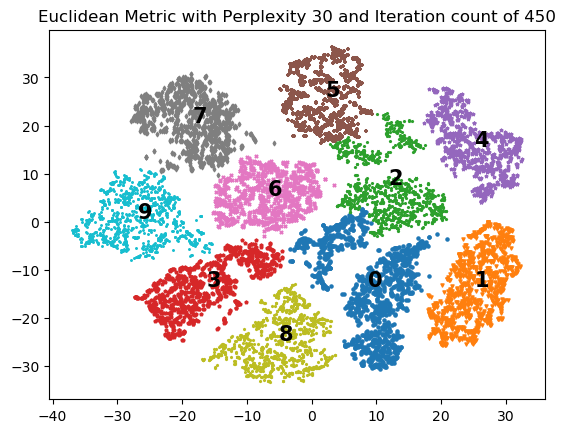

In [40]:
for i in range(10):
    selections = tsne_data[best_labels == i]
    plt.scatter(selections[:,0], selections[:,1], marker=MARKER[i], s=5)
    plt.title('Euclidean Metric with Perplexity 30 and Iteration count of 450')
    x, y = selections.mean(axis=0)
    plt.text(x, y, str(i), fontdict={'weight': 'bold', 'size': 15})    
plt.show()

**Is this data well suited to classification?** <br>
Of course! We already know that our data has 10 classes as they are representations of arabic hand written numbers. There is a pattern there already but with just PCA we could not accurately identify it due to many of the relations no being sequencial or linear. Images often have complex and local patterns that are captured by t-SNE's density based dimensional reduction and it shows with our Agglomerative clustering. Using PCA still removes a lot of noise from our data as there is a lot of blank space within for every image, though I did use the original normalized data before. This resulted in very similar clusters to what we see now at the cost of far more time due to all the excess noise in the data. <br><br>
**Are there points of confusion?** <br>
Definitely! It looks like cluster 0 has mislabelled parts of clusters 7 and 8. These points could be similar enough to the data points within cluster 0 to be mislabelled and are thus fringe cases, on the other hand we see clear distinctions in the visual representation. In our dataset we see that the representations of 6, 7, and 8 are all very similar and this may be what is happenign in our clustering model, causing confusion with messier handwriting. Another theory is that the representations of 2, 3, and 6 are close enough to cause this overlap in our clusters.<br><br>
This may be fixed with more strict clustering hyperparameters, or potentially fine tuning DBSCAN to a far better degree than I have done in this assignment. Otherwise we see very good seperations between all our clusters and likely have a system that will identify most images correctly. 